# Midterm 2 — Question 3  
## Manual neural network for nonlinear regression

This notebook solves **Question 3** from the Machine Learning Theory midterm.

We manually implement, from first principles, a neural network with:

- two input attributes: $x_1, x_2$;
- two hidden layers;
- two neurons per hidden layer;
- one output neuron;
- ReLU activation in every neuron, including the output neuron;
- explicit forward propagation;
- explicit error computation;
- explicit gradients for every weight and bias;
- explicit parameter updates using

$$
 w_{new} = w_{old} + \lambda \nabla_w.
$$

The notebook also compares the fitted model with:

1. the noisy observed target $y$;
2. the noiseless true signal $f(x_1,x_2)$;
3. an optional high-level dense neural network for extra credit.

## 1. Imports and reproducibility

Only `NumPy` is used for the manual neural network.  
`PyTorch` is used only in the optional extra-credit comparison section. If PyTorch is unavailable, the manual solution still runs.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility seed used for the synthetic data and deterministic splits.
SEED = 123
rng = np.random.default_rng(SEED)

# Make plots readable in notebooks.
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

## 2. Data simulation

The data-generating process is:

$$
x_1, x_2 \sim U(-2,2), \qquad \varepsilon \sim \mathcal{N}(0, 0.15^2),
$$

$$
f(x_1,x_2)=\max\left\{0,\,1.5+2\sin(\pi x_1)+0.75x_2^2-1.2x_1x_2\right\},
$$

$$
y=\max\{0, f(x_1,x_2)+\varepsilon\}.
$$

The true signal $f$ is noiseless. The observed variable $y$ is noisy but clipped below at zero.

In [2]:
def simulate_data(n: int = 3000, seed: int = 123):
    """Generate the synthetic regression data required by the assignment."""
    local_rng = np.random.default_rng(seed)

    X_raw = local_rng.uniform(-2, 2, size=(n, 2))
    x1 = X_raw[:, [0]]
    x2 = X_raw[:, [1]]

    epsilon = local_rng.normal(loc=0.0, scale=0.15, size=(n, 1))

    raw_signal = 1.5 + 2 * np.sin(np.pi * x1) + 0.75 * (x2 ** 2) - 1.2 * x1 * x2
    f_true = np.maximum(0, raw_signal)
    y = np.maximum(0, f_true + epsilon)

    return X_raw, f_true, y

X_raw, f_true, y = simulate_data(n=3000, seed=SEED)

print("X_raw shape:", X_raw.shape)
print("f_true shape:", f_true.shape)
print("y shape:", y.shape)
print("x1 range:", (X_raw[:, 0].min(), X_raw[:, 0].max()))
print("x2 range:", (X_raw[:, 1].min(), X_raw[:, 1].max()))
print("Observed y range:", (float(y.min()), float(y.max())))

X_raw shape: (3000, 2)
f_true shape: (3000, 1)
y shape: (3000, 1)
x1 range: (np.float64(-1.9999130966022673), np.float64(1.9953263300383108))
x2 range: (np.float64(-1.9992544808909254), np.float64(1.999413340676028))
Observed y range: (0.0, 10.108856070323368)


## 3. Train/validation/test split and input standardization

The manual neural network is trained on standardized inputs:

$$
\tilde{x}_j=\frac{x_j-\mu_j}{\sigma_j}.
$$

The standardization parameters are estimated only from the training set to avoid information leakage.

The target $y$ is not standardized because the output ReLU naturally matches the nonnegative scale of the response.

In [3]:
def split_data(X_raw, f_true, y, train_frac=0.70, val_frac=0.15, seed=123):
    """Split data into train, validation, and test sets."""
    n = X_raw.shape[0]
    local_rng = np.random.default_rng(seed)
    idx = local_rng.permutation(n)

    n_train = int(train_frac * n)
    n_val = int(val_frac * n)

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]

    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = split_data(X_raw, f_true, y, seed=SEED)

X_train_raw, X_val_raw, X_test_raw = X_raw[train_idx], X_raw[val_idx], X_raw[test_idx]
f_train, f_val, f_test = f_true[train_idx], f_true[val_idx], f_true[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

x_mean = X_train_raw.mean(axis=0, keepdims=True)
x_std = X_train_raw.std(axis=0, keepdims=True)

X_train = (X_train_raw - x_mean) / x_std
X_val = (X_val_raw - x_mean) / x_std
X_test = (X_test_raw - x_mean) / x_std

print("Training observations:", X_train.shape[0])
print("Validation observations:", X_val.shape[0])
print("Test observations:", X_test.shape[0])
print("Training mean used for scaling:", x_mean.ravel())
print("Training std used for scaling:", x_std.ravel())

Training observations: 2100
Validation observations: 450
Test observations: 450
Training mean used for scaling: [-0.05688475 -0.0179091 ]
Training std used for scaling: [1.15152588 1.12939735]


## 4. Exploratory plots of the simulated data

These plots verify the nonlinearity and the nonnegative clipping in the data-generating process.

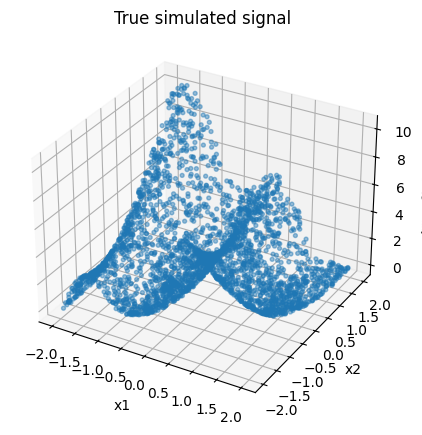

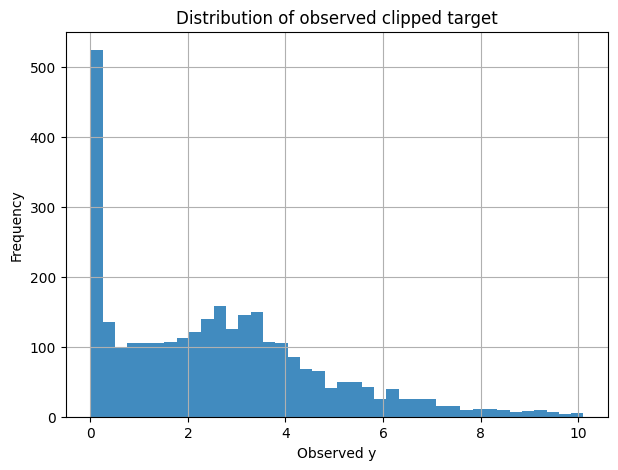

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_raw[:, 0], X_raw[:, 1], f_true.ravel(), s=8, alpha=0.45)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("true f(x1,x2)")
ax.set_title("True simulated signal")
plt.show()

plt.figure()
plt.hist(y.ravel(), bins=40, alpha=0.85)
plt.xlabel("Observed y")
plt.ylabel("Frequency")
plt.title("Distribution of observed clipped target")
plt.show()

## 5. Manual network architecture

For one observation $x_i=[x_{i1},x_{i2}]$, the network is:

### First hidden layer

$$
z_i^{(1)} = x_i W^{(1)} + b^{(1)}, \qquad a_i^{(1)} = \operatorname{ReLU}(z_i^{(1)}).
$$

Here:

$$
W^{(1)}\in \mathbb{R}^{2\times 2}, \qquad b^{(1)}\in \mathbb{R}^{1\times 2}.
$$

### Second hidden layer

$$
z_i^{(2)} = a_i^{(1)} W^{(2)} + b^{(2)}, \qquad a_i^{(2)} = \operatorname{ReLU}(z_i^{(2)}),
$$

with:

$$
W^{(2)}\in \mathbb{R}^{2\times 2}, \qquad b^{(2)}\in \mathbb{R}^{1\times 2}.
$$

### Output layer

$$
z_i^{(3)} = a_i^{(2)} W^{(3)} + b^{(3)}, \qquad \hat{y}_i = \operatorname{ReLU}(z_i^{(3)}),
$$

with:

$$
W^{(3)}\in \mathbb{R}^{2\times 1}, \qquad b^{(3)}\in \mathbb{R}^{1\times 1}.
$$

The total number of trainable parameters is:

$$
(2\cdot2+2)+(2\cdot2+2)+(2\cdot1+1)=15.
$$

## 6. Error function and sign convention for the requested update rule

The assignment asks us to update parameters as:

$$
\theta_{new}=\theta_{old}+\lambda \nabla_{\theta}.
$$

Ordinary mean squared error minimization is usually written with a minus sign:

$$
\theta_{new}=\theta_{old}-\lambda \frac{\partial L}{\partial \theta}.
$$

To match the requested plus-sign update exactly, this notebook defines the optimization objective as the **negative half-MSE**:

$$
J(\theta)=-\frac{1}{2m}\sum_{i=1}^{m}(y_i-\hat{y}_i)^2.
$$

Then maximizing $J$ by gradient ascent is equivalent to minimizing MSE. Therefore:

$$
\theta_{new}=\theta_{old}+\lambda \frac{\partial J}{\partial \theta}.
$$

For reporting, we still display the usual MSE:

$$
\operatorname{MSE}=\frac{1}{m}\sum_{i=1}^{m}(y_i-\hat{y}_i)^2.
$$

## 7. Backpropagation from first principles

Let:

$$
e_i = y_i-\hat{y}_i.
$$

Because

$$
J=-\frac{1}{2m}\sum_i e_i^2,
$$

we obtain:

$$
\frac{\partial J}{\partial \hat{y}_i}=\frac{e_i}{m}.
$$

The ReLU derivative is:

$$
\operatorname{ReLU}'(z)=
\begin{cases}
1, & z>0,\\
0, & z\le 0.
\end{cases}
$$

### Output-layer delta

$$
\delta_i^{(3)}=\frac{e_i}{m}\operatorname{ReLU}'(z_i^{(3)}).
$$

Therefore:

$$
\nabla_{W^{(3)}}J=(A^{(2)})^T\delta^{(3)}, \qquad
\nabla_{b^{(3)}}J=\sum_i \delta_i^{(3)}.
$$

### Second-hidden-layer delta

$$
\delta_i^{(2)}=\left(\delta_i^{(3)}(W^{(3)})^T\right)\odot \operatorname{ReLU}'(z_i^{(2)}).
$$

Therefore:

$$
\nabla_{W^{(2)}}J=(A^{(1)})^T\delta^{(2)}, \qquad
\nabla_{b^{(2)}}J=\sum_i \delta_i^{(2)}.
$$

### First-hidden-layer delta

$$
\delta_i^{(1)}=\left(\delta_i^{(2)}(W^{(2)})^T\right)\odot \operatorname{ReLU}'(z_i^{(1)}).
$$

Therefore:

$$
\nabla_{W^{(1)}}J=X^T\delta^{(1)}, \qquad
\nabla_{b^{(1)}}J=\sum_i \delta_i^{(1)}.
$$

All six parameter blocks are then updated explicitly:

$$
W^{(1)}, b^{(1)}, W^{(2)}, b^{(2)}, W^{(3)}, b^{(3)}.
$$

## 8. Manual implementation of ReLU, forward propagation, loss, gradients, and update

In [5]:
def relu(z):
    """ReLU activation function."""
    return np.maximum(0, z)


def drelu(z):
    """Derivative of ReLU. At z = 0 we use 0, a common valid subgradient choice."""
    return (z > 0).astype(float)


def initialize_parameters(seed: int, y_reference: np.ndarray):
    """
    Initialize all 15 trainable parameters of the 2-2-2-1 ReLU network.

    The output bias is initialized near the mean target to reduce the probability
    of a completely inactive output ReLU at the beginning of training.
    """
    local_rng = np.random.default_rng(seed)

    params = {
        "W1": local_rng.normal(loc=0.0, scale=1.0, size=(2, 2)),
        "b1": np.full((1, 2), 0.10),
        "W2": local_rng.normal(loc=0.0, scale=1.0, size=(2, 2)),
        "b2": np.full((1, 2), 0.10),
        "W3": local_rng.normal(loc=0.0, scale=1.0, size=(2, 1)),
        "b3": np.array([[float(y_reference.mean())]]),
    }
    return params


def forward_propagation(X: np.ndarray, params: dict):
    """Compute all pre-activations, activations, and final prediction manually."""
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)

    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = relu(Z2)

    Z3 = A2 @ params["W3"] + params["b3"]
    Y_hat = relu(Z3)

    cache = {
        "X": X,
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2,
        "Z3": Z3,
        "Y_hat": Y_hat,
    }
    return Y_hat, cache


def mse_loss(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Mean squared error used for reporting."""
    return float(np.mean((y_true - y_pred) ** 2))


def compute_gradients(cache: dict, y_true: np.ndarray, params: dict):
    """
    Compute gradients of J = -1/(2m) * sum((y - y_hat)^2)
    with respect to every weight and bias.

    Because J is negative half-MSE, the update params += lr * grads
    is equivalent to gradient descent on MSE.
    """
    X = cache["X"]
    Z1, A1 = cache["Z1"], cache["A1"]
    Z2, A2 = cache["Z2"], cache["A2"]
    Z3, Y_hat = cache["Z3"], cache["Y_hat"]

    m = y_true.shape[0]
    error = y_true - Y_hat

    # Output layer: delta3 has shape (m, 1)
    delta3 = (error / m) * drelu(Z3)
    grad_W3 = A2.T @ delta3
    grad_b3 = np.sum(delta3, axis=0, keepdims=True)

    # Second hidden layer: delta2 has shape (m, 2)
    delta2 = (delta3 @ params["W3"].T) * drelu(Z2)
    grad_W2 = A1.T @ delta2
    grad_b2 = np.sum(delta2, axis=0, keepdims=True)

    # First hidden layer: delta1 has shape (m, 2)
    delta1 = (delta2 @ params["W2"].T) * drelu(Z1)
    grad_W1 = X.T @ delta1
    grad_b1 = np.sum(delta1, axis=0, keepdims=True)

    gradients = {
        "W1": grad_W1,
        "b1": grad_b1,
        "W2": grad_W2,
        "b2": grad_b2,
        "W3": grad_W3,
        "b3": grad_b3,
    }
    return gradients


def update_parameters(params: dict, gradients: dict, learning_rate: float):
    """Apply theta_new = theta_old + lambda * gradient for every parameter block."""
    for key in params:
        params[key] = params[key] + learning_rate * gradients[key]
    return params


def count_manual_parameters(params: dict) -> int:
    """Count all trainable scalar parameters."""
    return sum(value.size for value in params.values())

## 9. Training the manual network

The network is tiny and highly constrained, so different random initializations can converge to different local optima.  
To reduce the chance of reporting a bad initialization, we train several manual restarts and select the one with the lowest validation MSE.

This does not change the architecture; it only makes the experiment more stable.

In [6]:
def train_manual_network(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate=0.06,
    epochs=8000,
    seeds=range(8),
    log_every=200,
):
    """Train the manual 2-2-2-1 ReLU network using full-batch gradient ascent on J."""
    best = {
        "val_mse": np.inf,
        "seed": None,
        "params": None,
        "history": None,
        "elapsed_seconds": None,
    }

    all_runs = []

    for seed in seeds:
        params = initialize_parameters(seed=seed, y_reference=y_train)
        history = []
        start = time.perf_counter()

        for epoch in range(epochs + 1):
            y_hat_train, cache = forward_propagation(X_train, params)

            if epoch % log_every == 0:
                y_hat_val, _ = forward_propagation(X_val, params)
                train_mse = mse_loss(y_train, y_hat_train)
                val_mse = mse_loss(y_val, y_hat_val)
                history.append({"epoch": epoch, "train_mse": train_mse, "val_mse": val_mse})

            if epoch < epochs:
                gradients = compute_gradients(cache, y_train, params)
                params = update_parameters(params, gradients, learning_rate)

        elapsed = time.perf_counter() - start
        y_hat_val, _ = forward_propagation(X_val, params)
        final_val_mse = mse_loss(y_val, y_hat_val)

        all_runs.append({"seed": seed, "val_mse": final_val_mse, "elapsed_seconds": elapsed})

        if final_val_mse < best["val_mse"]:
            best.update(
                {
                    "val_mse": final_val_mse,
                    "seed": seed,
                    "params": {k: v.copy() for k, v in params.items()},
                    "history": pd.DataFrame(history),
                    "elapsed_seconds": elapsed,
                }
            )

    return best, pd.DataFrame(all_runs)

manual_best, manual_runs = train_manual_network(X_train, y_train, X_val, y_val)

print("Validation MSE by manual restart:")
display(manual_runs)

print("Best manual seed:", manual_best["seed"])
print("Best manual validation MSE:", manual_best["val_mse"])
print("Manual train time for best seed, seconds:", manual_best["elapsed_seconds"])
print("Manual parameter count:", count_manual_parameters(manual_best["params"]))

Validation MSE by manual restart:


,seed,val_mse,elapsed_seconds
0,0,3.668312,1.741353
1,1,1.549950,1.742471
2,2,1.604442,1.704150
3,3,3.703869,1.743151
4,4,2.892518,1.766922
5,5,3.703881,1.719596
6,6,2.990101,1.843901
7,7,1.899794,1.877207


Best manual seed: 1
Best manual validation MSE: 1.5499504405313038
Manual train time for best seed, seconds: 1.742470729000047
Manual parameter count: 15


## 10. Manual training curve

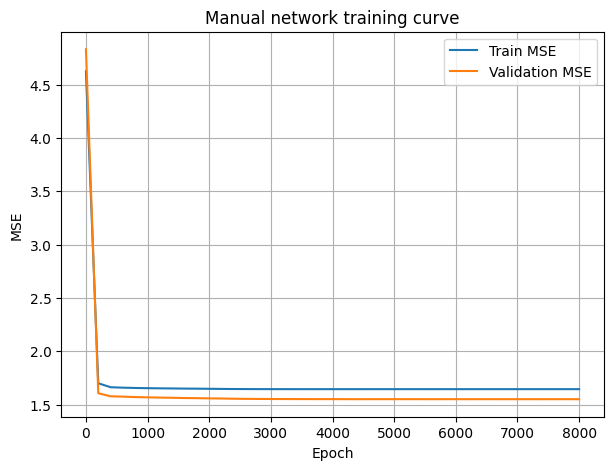

In [7]:
history = manual_best["history"]

plt.figure()
plt.plot(history["epoch"], history["train_mse"], label="Train MSE")
plt.plot(history["epoch"], history["val_mse"], label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Manual network training curve")
plt.legend()
plt.show()

## 11. Regression metrics

We evaluate the same predictions in two ways:

1. **Against observed values** $y$, which include noise.
2. **Against the true signal** $f(x_1,x_2)$, which is the noiseless function.

The metrics are:

$$
\operatorname{MAE}=\frac{1}{n}\sum_i |y_i-\hat{y}_i|,
$$

$$
\operatorname{RMSE}=\sqrt{\frac{1}{n}\sum_i (y_i-\hat{y}_i)^2},
$$

$$
R^2=1-\frac{\sum_i (y_i-\hat{y}_i)^2}{\sum_i (y_i-\bar{y})^2}.
$$

In [8]:
def regression_metrics(target: np.ndarray, prediction: np.ndarray):
    """Return MAE, RMSE, and R^2."""
    residual = target - prediction
    mae = float(np.mean(np.abs(residual)))
    rmse = float(np.sqrt(np.mean(residual ** 2)))
    ss_res = float(np.sum(residual ** 2))
    ss_tot = float(np.sum((target - target.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

manual_yhat_test, _ = forward_propagation(X_test, manual_best["params"])

manual_metrics_observed = regression_metrics(y_test, manual_yhat_test)
manual_metrics_true = regression_metrics(f_test, manual_yhat_test)

manual_metrics_table = pd.DataFrame(
    [manual_metrics_observed, manual_metrics_true],
    index=["Manual NN vs observed y", "Manual NN vs true f"],
)

display(manual_metrics_table)

,MAE,RMSE,R2
Manual NN vs observed y,1.118663,1.276247,0.648227
Manual NN vs true f,1.121893,1.275792,0.649172


## 12. Prediction-versus-target plots

The closer the points are to the dashed diagonal, the better the predictions.

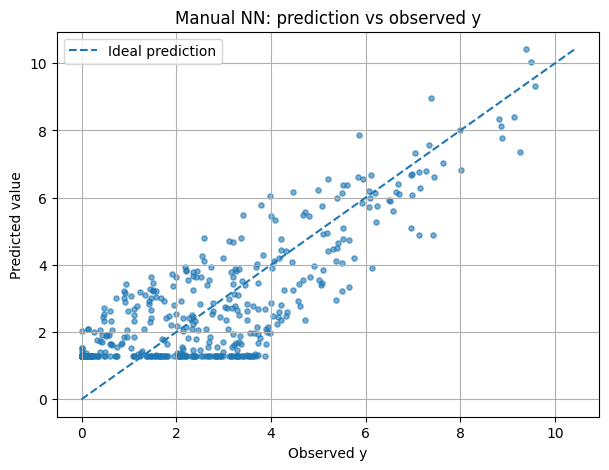

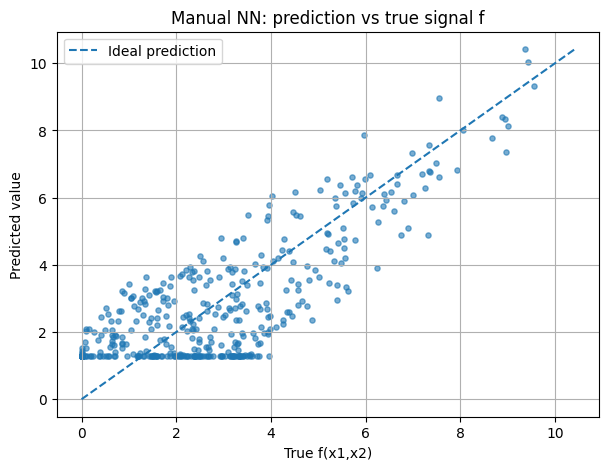

In [9]:
def prediction_plot(target, prediction, title, xlabel):
    """Create a prediction-versus-target scatter plot with a diagonal reference line."""
    target_flat = target.ravel()
    pred_flat = prediction.ravel()

    lo = min(target_flat.min(), pred_flat.min())
    hi = max(target_flat.max(), pred_flat.max())

    plt.figure()
    plt.scatter(target_flat, pred_flat, s=14, alpha=0.6)
    plt.plot([lo, hi], [lo, hi], linestyle="--", label="Ideal prediction")
    plt.xlabel(xlabel)
    plt.ylabel("Predicted value")
    plt.title(title)
    plt.legend()
    plt.show()

prediction_plot(y_test, manual_yhat_test, "Manual NN: prediction vs observed y", "Observed y")
prediction_plot(f_test, manual_yhat_test, "Manual NN: prediction vs true signal f", "True f(x1,x2)")

## 13. Residual plot

A residual plot helps identify systematic underfitting. Because the manual network has only 15 parameters, it may not represent all the curvature and oscillation of the true function.

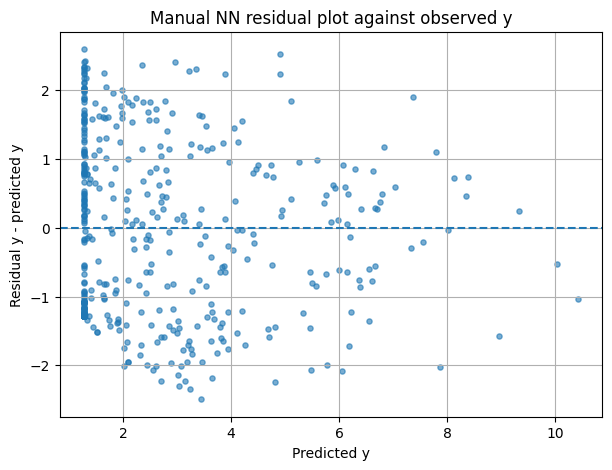

In [10]:
manual_residuals = y_test - manual_yhat_test

plt.figure()
plt.scatter(manual_yhat_test.ravel(), manual_residuals.ravel(), s=14, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted y")
plt.ylabel("Residual y - predicted y")
plt.title("Manual NN residual plot against observed y")
plt.show()

## 14. Learned manual parameters

The following cell prints the final weights and biases for reproducibility.

In [11]:
for name, value in manual_best["params"].items():
    print(f"{name} shape {value.shape}")
    print(value)
    print()

W1 shape (2, 2)
[[-0.94641784  0.76451421]
 [ 1.18293092 -1.55118739]]

b1 shape (1, 2)
[[-0.48504021  0.34502471]]

W2 shape (2, 2)
[[ 1.43998699  1.10188697]
 [-0.55219113  1.02319097]]

b2 shape (1, 2)
[[-7.75422881e-04 -1.67077378e+00]]

W3 shape (2, 1)
[[1.18136839]
 [2.14312422]]

b3 shape (1, 1)
[[1.28205591]]



## 15. Extra credit: high-level dense neural network

For comparison, we train a more expressive dense ReLU network using a high-level library.  
The model has two hidden layers with 32 neurons each and a ReLU output:

$$
2 \rightarrow 32 \rightarrow 32 \rightarrow 1.
$$

This model has many more parameters than the manual network, so it should approximate the simulated nonlinear function more accurately, but with lower interpretability and more computational machinery.

In [12]:
high_level_result = None

try:
    import torch

    # One thread gives stable and fast CPU execution in many notebook environments.
    torch.set_num_threads(1)
    torch.manual_seed(SEED)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)

    high_model = torch.nn.Sequential(
        torch.nn.Linear(2, 32),
        torch.nn.ReLU(),
        torch.nn.Linear(32, 32),
        torch.nn.ReLU(),
        torch.nn.Linear(32, 1),
        torch.nn.ReLU(),
    )

    optimizer = torch.optim.Adam(high_model.parameters(), lr=0.01)
    loss_fn = torch.nn.MSELoss()

    best_val = np.inf
    best_state = None
    patience = 50
    bad_steps = 0
    high_history = []

    start = time.perf_counter()
    for epoch in range(1001):
        high_model.train()
        optimizer.zero_grad()
        train_pred = high_model(X_train_t)
        train_loss = loss_fn(train_pred, y_train_t)
        train_loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            high_model.eval()
            with torch.no_grad():
                val_loss = loss_fn(high_model(X_val_t), y_val_t).item()

            high_history.append(
                {"epoch": epoch, "train_mse": float(train_loss.item()), "val_mse": float(val_loss)}
            )

            if val_loss < best_val - 1e-6:
                best_val = val_loss
                best_state = {k: v.detach().clone() for k, v in high_model.state_dict().items()}
                bad_steps = 0
            else:
                bad_steps += 1

            if bad_steps >= patience:
                break

    high_elapsed = time.perf_counter() - start

    high_model.load_state_dict(best_state)
    high_model.eval()
    with torch.no_grad():
        high_yhat_test = high_model(X_test_t).numpy()

    high_level_result = {
        "library": "PyTorch",
        "prediction": high_yhat_test,
        "history": pd.DataFrame(high_history),
        "elapsed_seconds": high_elapsed,
        "param_count": sum(p.numel() for p in high_model.parameters()),
        "best_val_mse": best_val,
    }

    print("High-level library:", high_level_result["library"])
    print("High-level parameter count:", high_level_result["param_count"])
    print("Best high-level validation MSE:", high_level_result["best_val_mse"])
    print("High-level elapsed seconds:", high_level_result["elapsed_seconds"])

except Exception as exc:
    print("The high-level comparison was skipped because PyTorch is unavailable or failed.")
    print("Reason:", repr(exc))

High-level library: PyTorch
High-level parameter count: 1185
Best high-level validation MSE: 0.02539420686662197
High-level elapsed seconds: 1.015960060999987


## 16. High-level dense network metrics and plots

,Model,Parameters,"Training time, s",Target compared,MAE,RMSE,R2
0,Manual 2-2-2-1 ReLU NN,15,1.742471,observed y,1.118663,1.276247,0.648227
1,Manual 2-2-2-1 ReLU NN,15,1.742471,true f,1.121893,1.275792,0.649172
2,High-level 2-32-32-1 ReLU NN,1185,1.015960,observed y,0.134966,0.180920,0.992931
3,High-level 2-32-32-1 ReLU NN,1185,1.015960,true f,0.068720,0.102365,0.997741


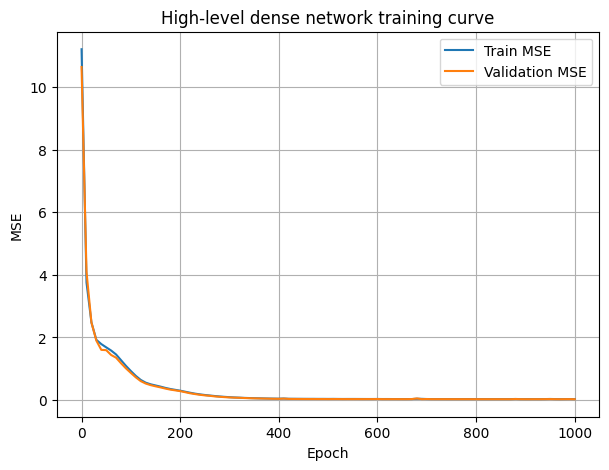

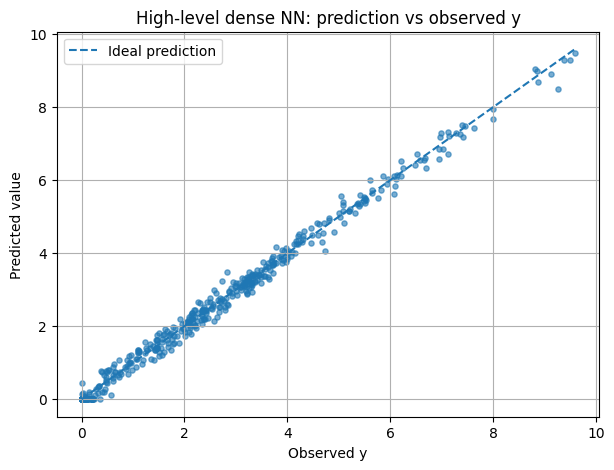

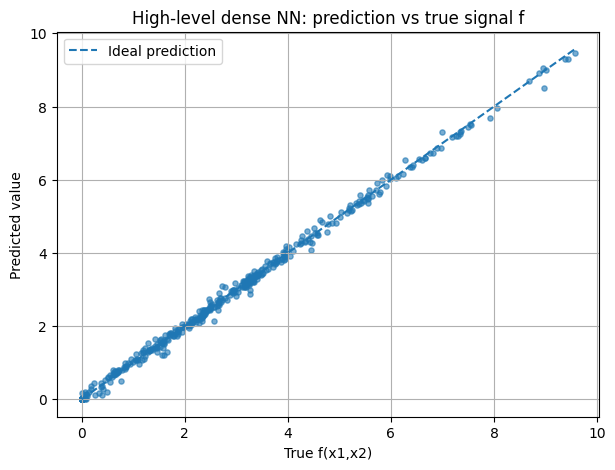

In [13]:
if high_level_result is not None:
    high_metrics_observed = regression_metrics(y_test, high_level_result["prediction"])
    high_metrics_true = regression_metrics(f_test, high_level_result["prediction"])

    comparison_table = pd.DataFrame(
        [
            {
                "Model": "Manual 2-2-2-1 ReLU NN",
                "Parameters": count_manual_parameters(manual_best["params"]),
                "Training time, s": manual_best["elapsed_seconds"],
                "Target compared": "observed y",
                **manual_metrics_observed,
            },
            {
                "Model": "Manual 2-2-2-1 ReLU NN",
                "Parameters": count_manual_parameters(manual_best["params"]),
                "Training time, s": manual_best["elapsed_seconds"],
                "Target compared": "true f",
                **manual_metrics_true,
            },
            {
                "Model": "High-level 2-32-32-1 ReLU NN",
                "Parameters": high_level_result["param_count"],
                "Training time, s": high_level_result["elapsed_seconds"],
                "Target compared": "observed y",
                **high_metrics_observed,
            },
            {
                "Model": "High-level 2-32-32-1 ReLU NN",
                "Parameters": high_level_result["param_count"],
                "Training time, s": high_level_result["elapsed_seconds"],
                "Target compared": "true f",
                **high_metrics_true,
            },
        ]
    )

    display(comparison_table)

    plt.figure()
    plt.plot(high_level_result["history"]["epoch"], high_level_result["history"]["train_mse"], label="Train MSE")
    plt.plot(high_level_result["history"]["epoch"], high_level_result["history"]["val_mse"], label="Validation MSE")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title("High-level dense network training curve")
    plt.legend()
    plt.show()

    prediction_plot(
        y_test,
        high_level_result["prediction"],
        "High-level dense NN: prediction vs observed y",
        "Observed y",
    )

    prediction_plot(
        f_test,
        high_level_result["prediction"],
        "High-level dense NN: prediction vs true signal f",
        "True f(x1,x2)",
    )
else:
    print("No high-level result is available to compare.")

## 17. Discussion

### Manual network

The manual network satisfies the exact requested architecture: two inputs, two hidden layers, two neurons in each hidden layer, and one ReLU output neuron. It has only 15 trainable parameters. This makes it interpretable and easy to audit: every activation, delta, gradient, and update is explicitly visible.

However, this architecture is very small for the simulated function. The true signal contains:

- a sinusoidal component $2\sin(\pi x_1)$;
- a quadratic component $0.75x_2^2$;
- an interaction term $-1.2x_1x_2$;
- a final nonnegative clipping operation.

A 2-2-2-1 ReLU network represents a limited piecewise-linear function. Therefore, it can approximate the broad shape of the response but cannot perfectly represent the oscillation and curvature of the true signal. This is expected underfitting, not necessarily an implementation error.

### High-level dense network

The high-level dense model uses many more parameters. Consequently, it has greater capacity to approximate nonlinear curvature and interactions. Its prediction-vs-target plots should be closer to the ideal diagonal and its RMSE/R² should usually be better.

The tradeoff is interpretability. The manual model exposes every scalar operation and every gradient. The larger dense model is easier to train and often more accurate, but its learned representation is harder to inspect directly.

### Training stability

The manual model is trained with full-batch gradient updates and plain gradient ascent on negative MSE. Because ReLU derivatives become zero on inactive units, poor initialization can lead to dead or weakly active paths. That is why several random restarts were used and the best validation run was selected.

The high-level model uses Adam, an adaptive optimizer, and has more neurons. This usually improves training stability and convergence speed, but it also moves further away from the transparent first-principles update rule required in the main question.

### Computational time

The manual model is extremely small, but the Python/NumPy implementation is intentionally explicit rather than optimized as a production deep-learning framework. The high-level implementation is more optimized internally, even though the model has many more parameters.

### Final conclusion

The manual network is the correct object for demonstrating backpropagation from first principles. The high-level network is the better predictive tool. The difference in performance is explained mainly by model capacity, optimization method, and the nonlinear complexity of the simulated data-generating process.